# 01 — Cycle length and deviation by age, BMI, and workout intensity

Reproduces **Figure 1** (cycle length and deviation vs age) and supplementary figures
**S1** (cycle length × age distribution heatmap), **S2** (cycle length and deviation vs BMI),
**S3** (cycle length and deviation vs workout intensity), and
**S4** (within-user cycle-length SD vs age) from
*"The menstrual cycle through the lens of a wearable device"*.

All models are GEEs (Gaussian or Binomial) with exchangeable covariance per
participant, fit via `statsmodels.formula.api.gee`. Population-level predictions
are computed at subject-mean covariates by `StatisticalPredictionHandler`.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from menstrual_cycle_analysis import (
    CycleLengthAnalyses,
    StatisticalPredictionHandler,
    load_paper_data,
)

np.random.seed(42)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

## Load data

First call parses the CSVs and runs the cycle-table preprocessing pipeline
(~30 s for 1.4 M rows). Cohort is the paper's 2,596 women / 42,759 cycles.

In [2]:
day_df, CBM = load_paper_data()

CBM.add_sleep_behaviors('user')
CBM.add_sleep_behaviors('cycle')
CBM.add_workout_behaviors('user')
CBM.add_workout_behaviors('cycle')

cla = CycleLengthAnalyses(CBM=CBM)

print(f"Users:  {CBM.tables['user'].shape[0]:,}")
print(f"Cycles: {CBM.tables['cycle'].shape[0]:,}")

Users:  2,596
Cycles: 42,759


## Figure 1 — cycle length and deviation vs age

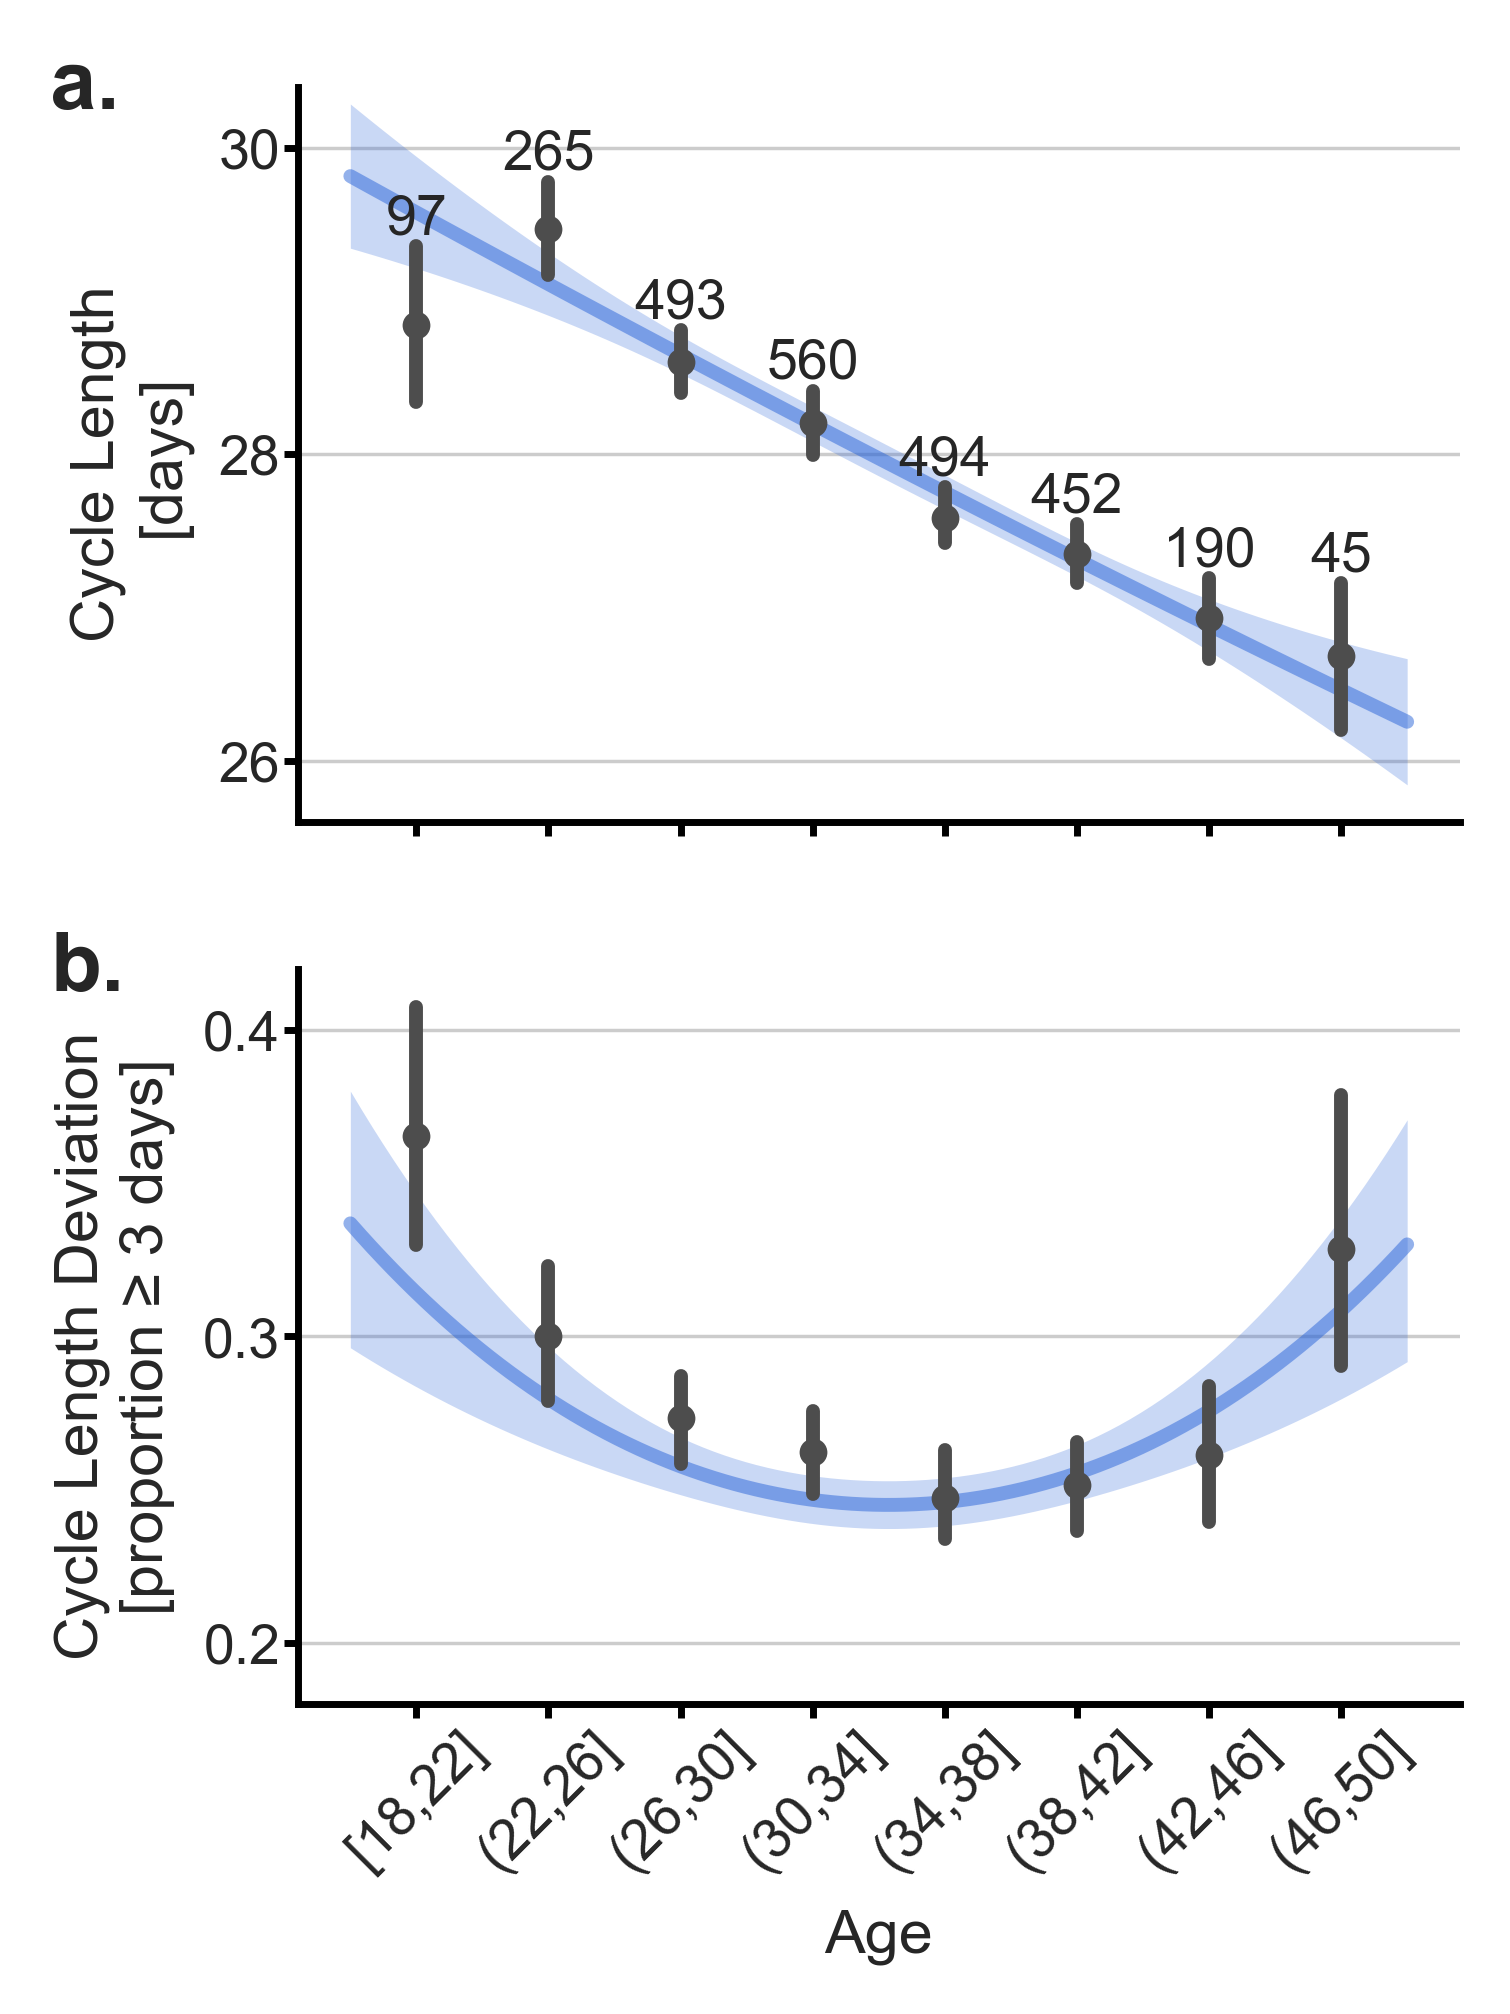

In [3]:
f, ax = cla.cl_x_age_plots(save_fig=False)
plt.show()

In [4]:
cla.cl_x_age_stats()


------------
Mean cycle length
 28.0
   age       pred  pred_ci_lower  pred_ci_upper
0   24  29.111313      28.907305      29.315322
1   44  26.884080      26.714895      27.053265
contrast
   contrast  contrast_ci_lower  contrast_ci_upper
0      -2.2               -2.5               -2.0

------------
Proportion of cycles with delta >= 3 days
 0.27


   age  pred  pred_ci_lower  pred_ci_upper
0   24  0.28           0.26           0.30
1   33  0.25           0.24           0.25
2   44  0.28           0.26           0.29
   min_x  ci_lower  ci_upper  median_cl
0   3.88      1.92      5.84      27.62

------------
Cycle length standard deviation
 2.93


   age  pred  pred_ci_lower  pred_ci_upper
0   24  3.00           2.86           3.14
1   32  2.75           2.68           2.81
2   33  2.75           2.68           2.82
3   44  3.22           3.09           3.36
   min_x  ci_lower  ci_upper  mean_cl
0  32.22     30.72     33.72    27.81


In [5]:
panel = 'cl_mean_age'
m = cla.get_model(panel)
print(m.summary())

                               GEE Regression Results                              
Dep. Variable:                cycle_length   No. Observations:                42759
Model:                                 GEE   No. clusters:                     2596
Method:                        Generalized   Min. cluster size:                   5
                      Estimating Equations   Max. cluster size:                  28
Family:                           Gaussian   Mean cluster size:                16.5
Dependence structure:         Exchangeable   Num. iterations:                     8
Date:                     Fri, 08 May 2026   Scale:                          14.422
Covariance type:                    robust   Time:                         11:29:48
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     32.7151      1.402     23.340      0.000      29.968      35.462
age    

In [6]:
panel = 'cl_p3_age'
m = cla.get_model(panel, overwrite=True)
print(m.summary())

                               GEE Regression Results                              
Dep. Variable:             a_delta_cl_ge_3   No. Observations:                42759
Model:                                 GEE   No. clusters:                     2596
Method:                        Generalized   Min. cluster size:                   5
                      Estimating Equations   Max. cluster size:                  28
Family:                           Binomial   Mean cluster size:                16.5
Dependence structure:         Exchangeable   Num. iterations:                     7
Date:                     Fri, 08 May 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         11:29:49
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          9.3387      4.284      2.180      0.029       0.942      17

## Figure S1 — cycle-length distribution by age

Heatmap is saved as PNG only (SVG too large for this dense annotated output).

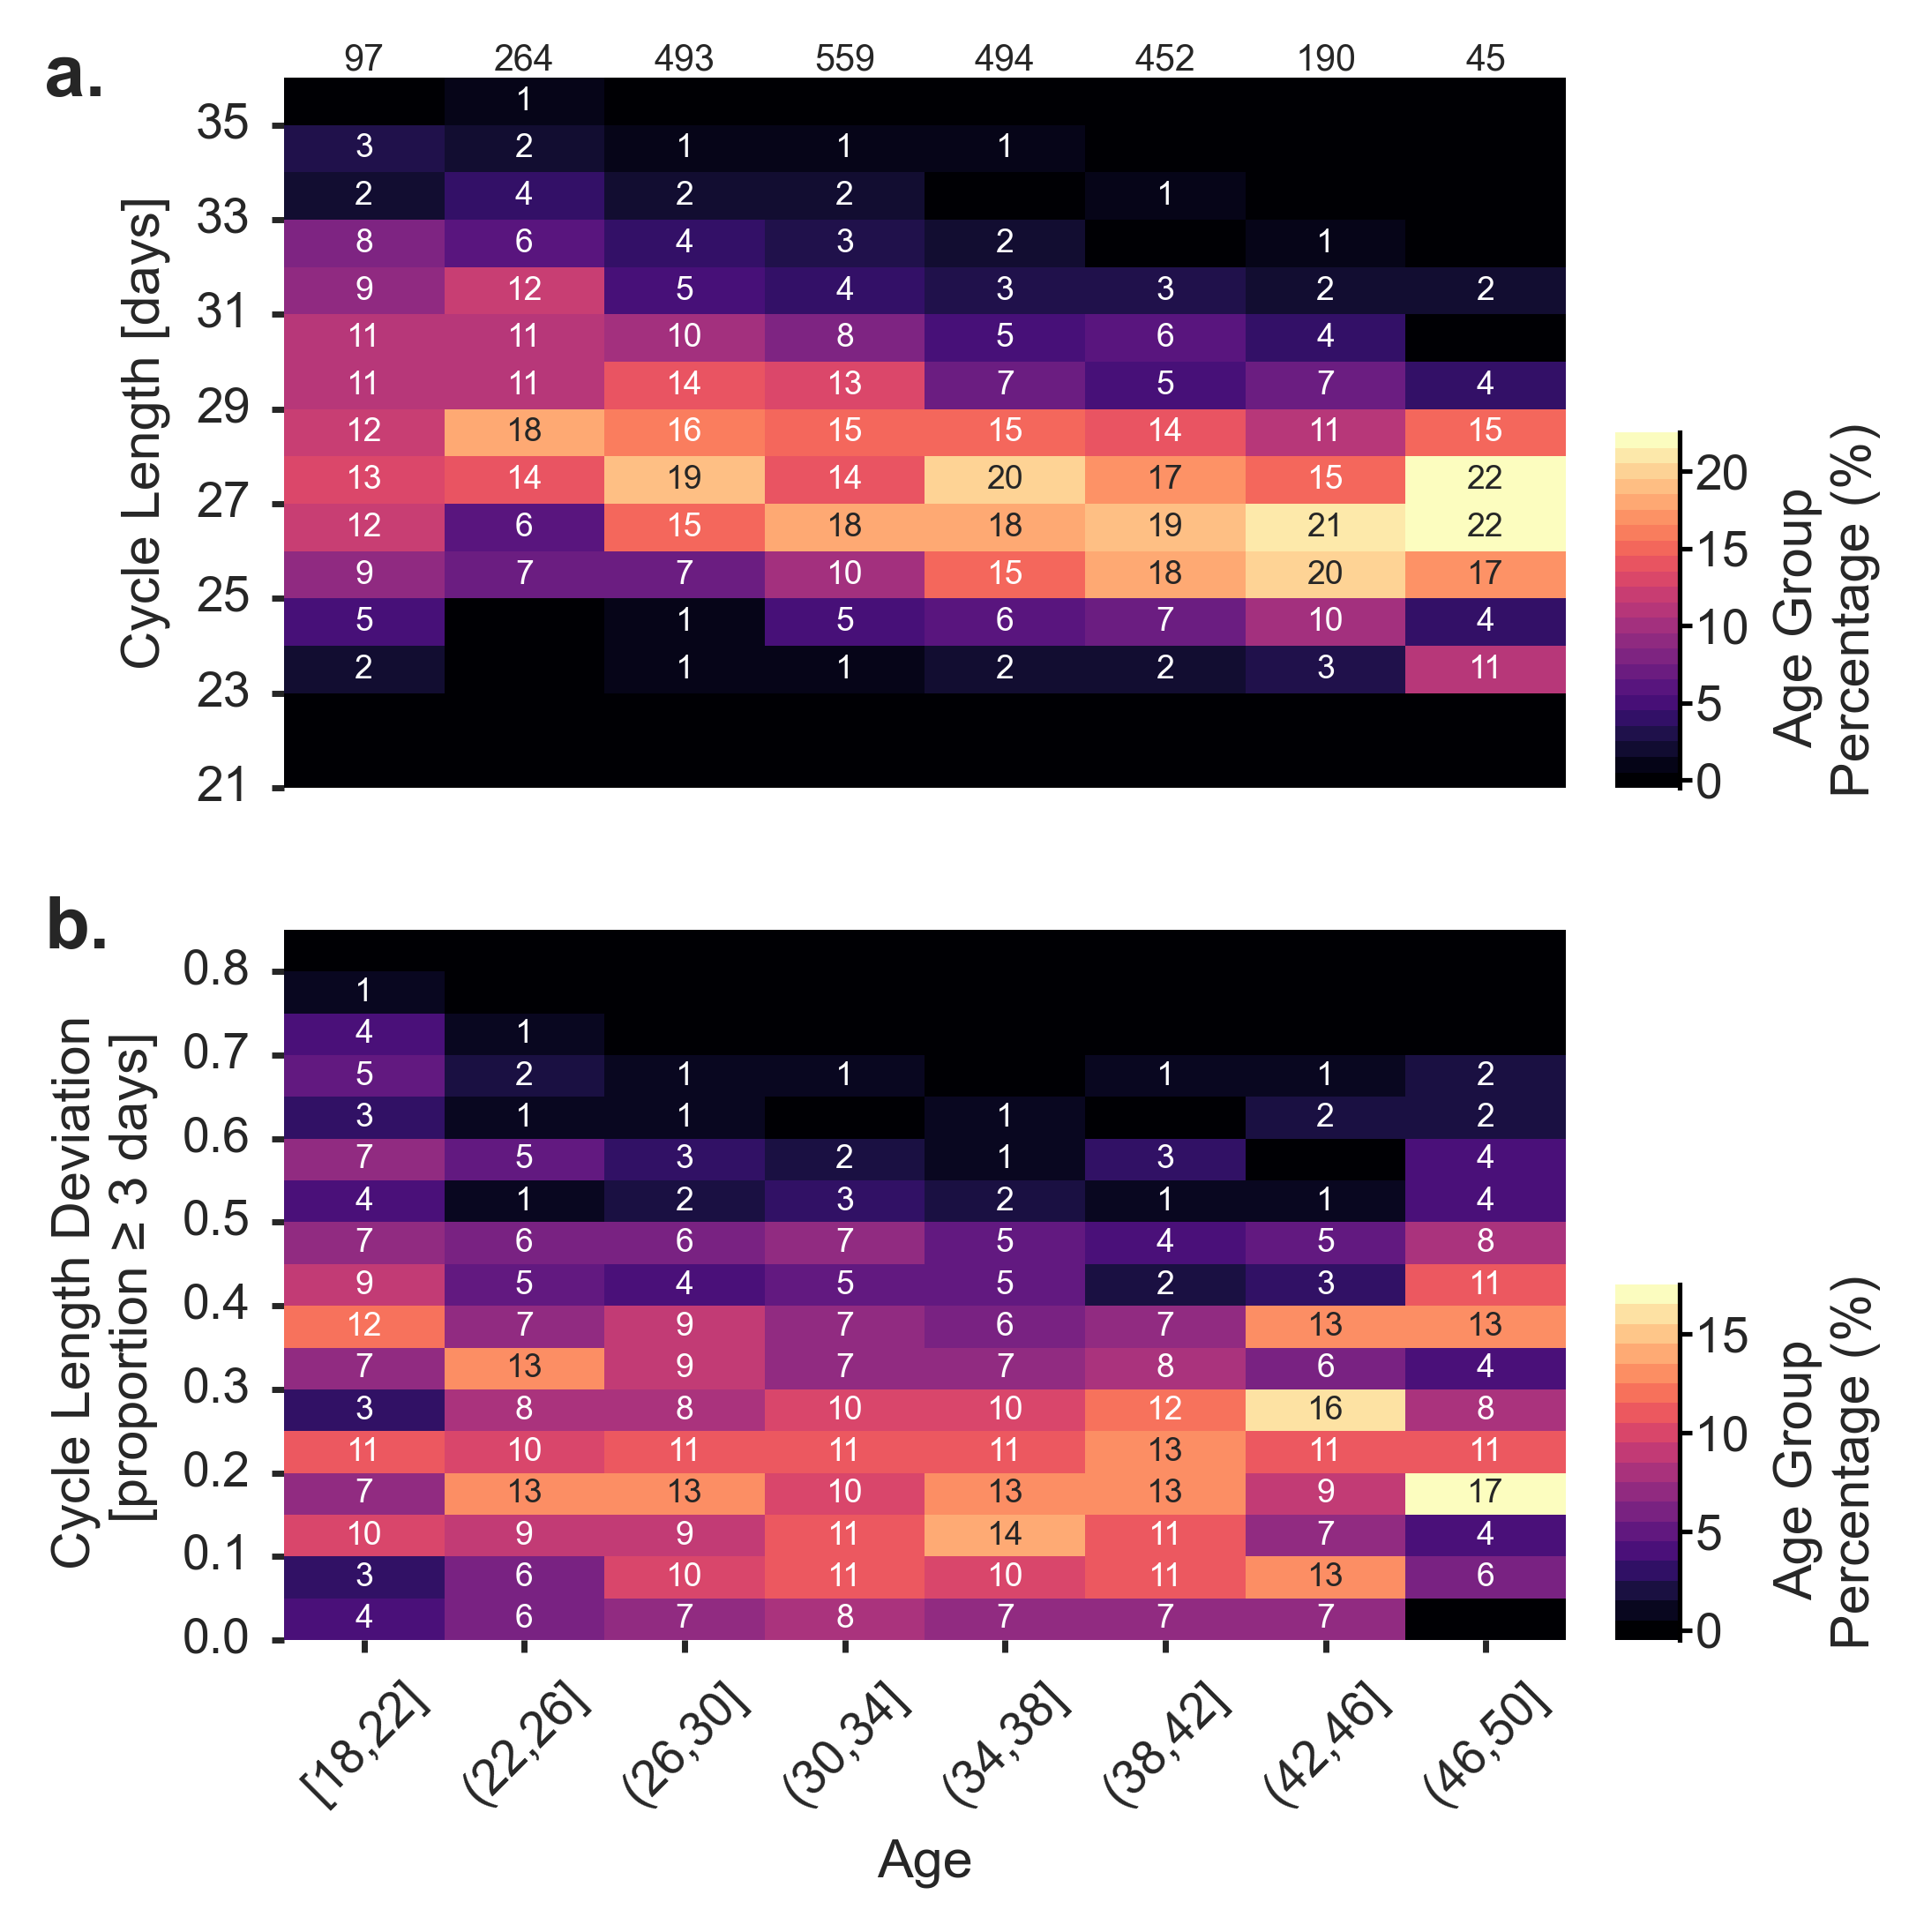

In [7]:
cla.cl_x_age_dist_plots(save_fig=False)

## Figure S2 — cycle length and deviation vs BMI

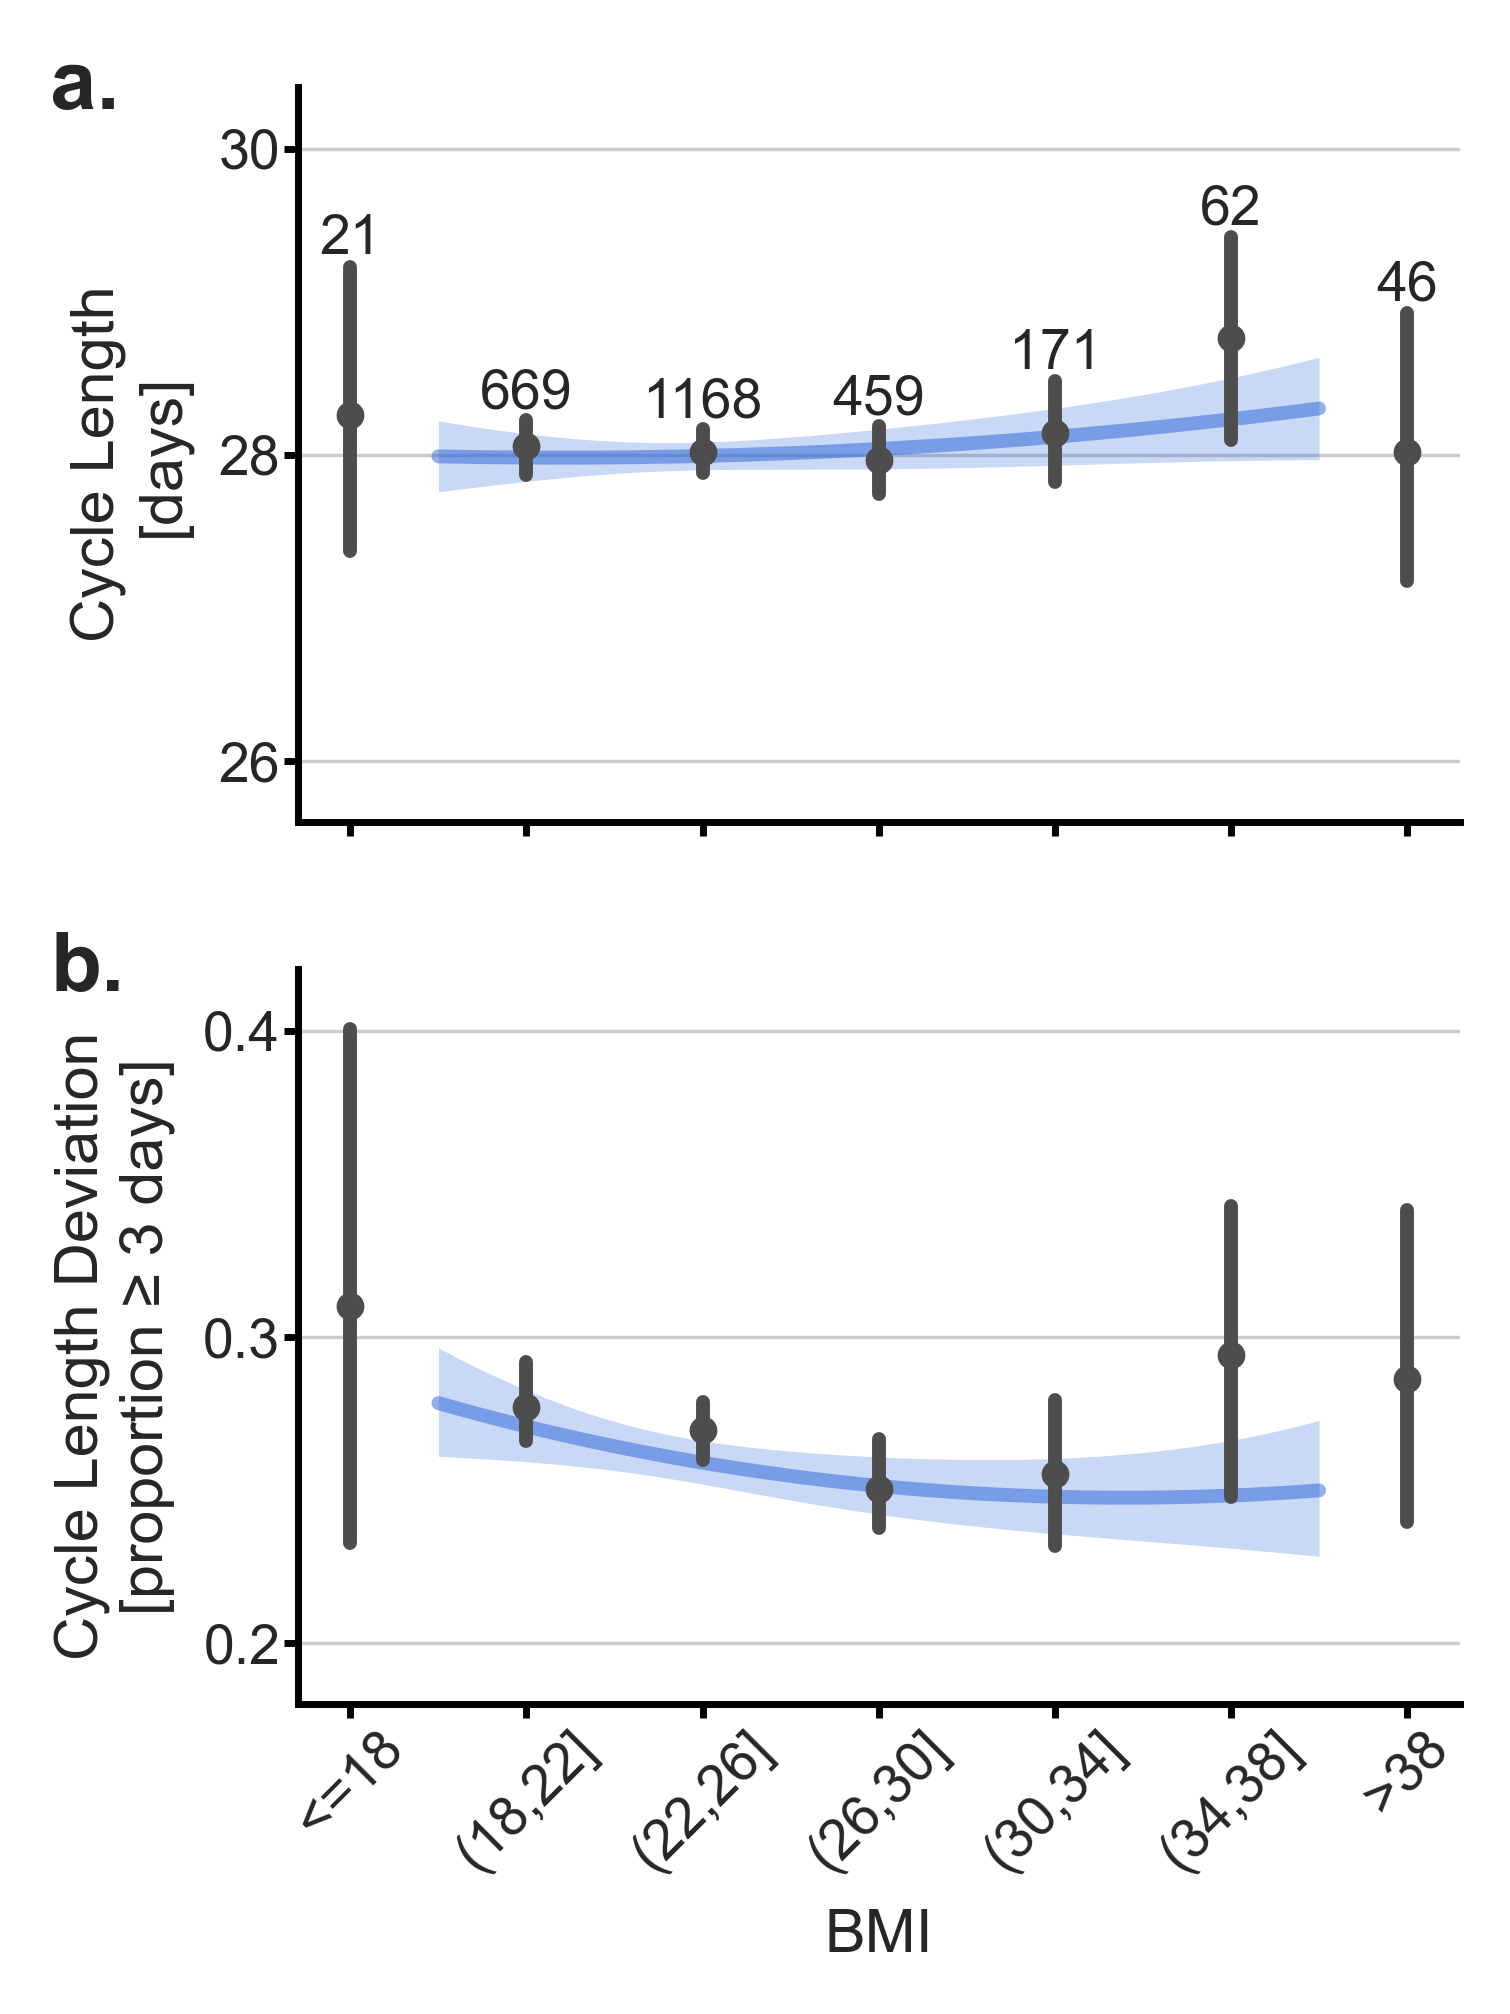

In [8]:
f, ax = cla.cl_x_bmi_plots(save_fig=False)
plt.show()

## Figure S3 — cycle length and deviation vs workout intensity (eTRIMP)

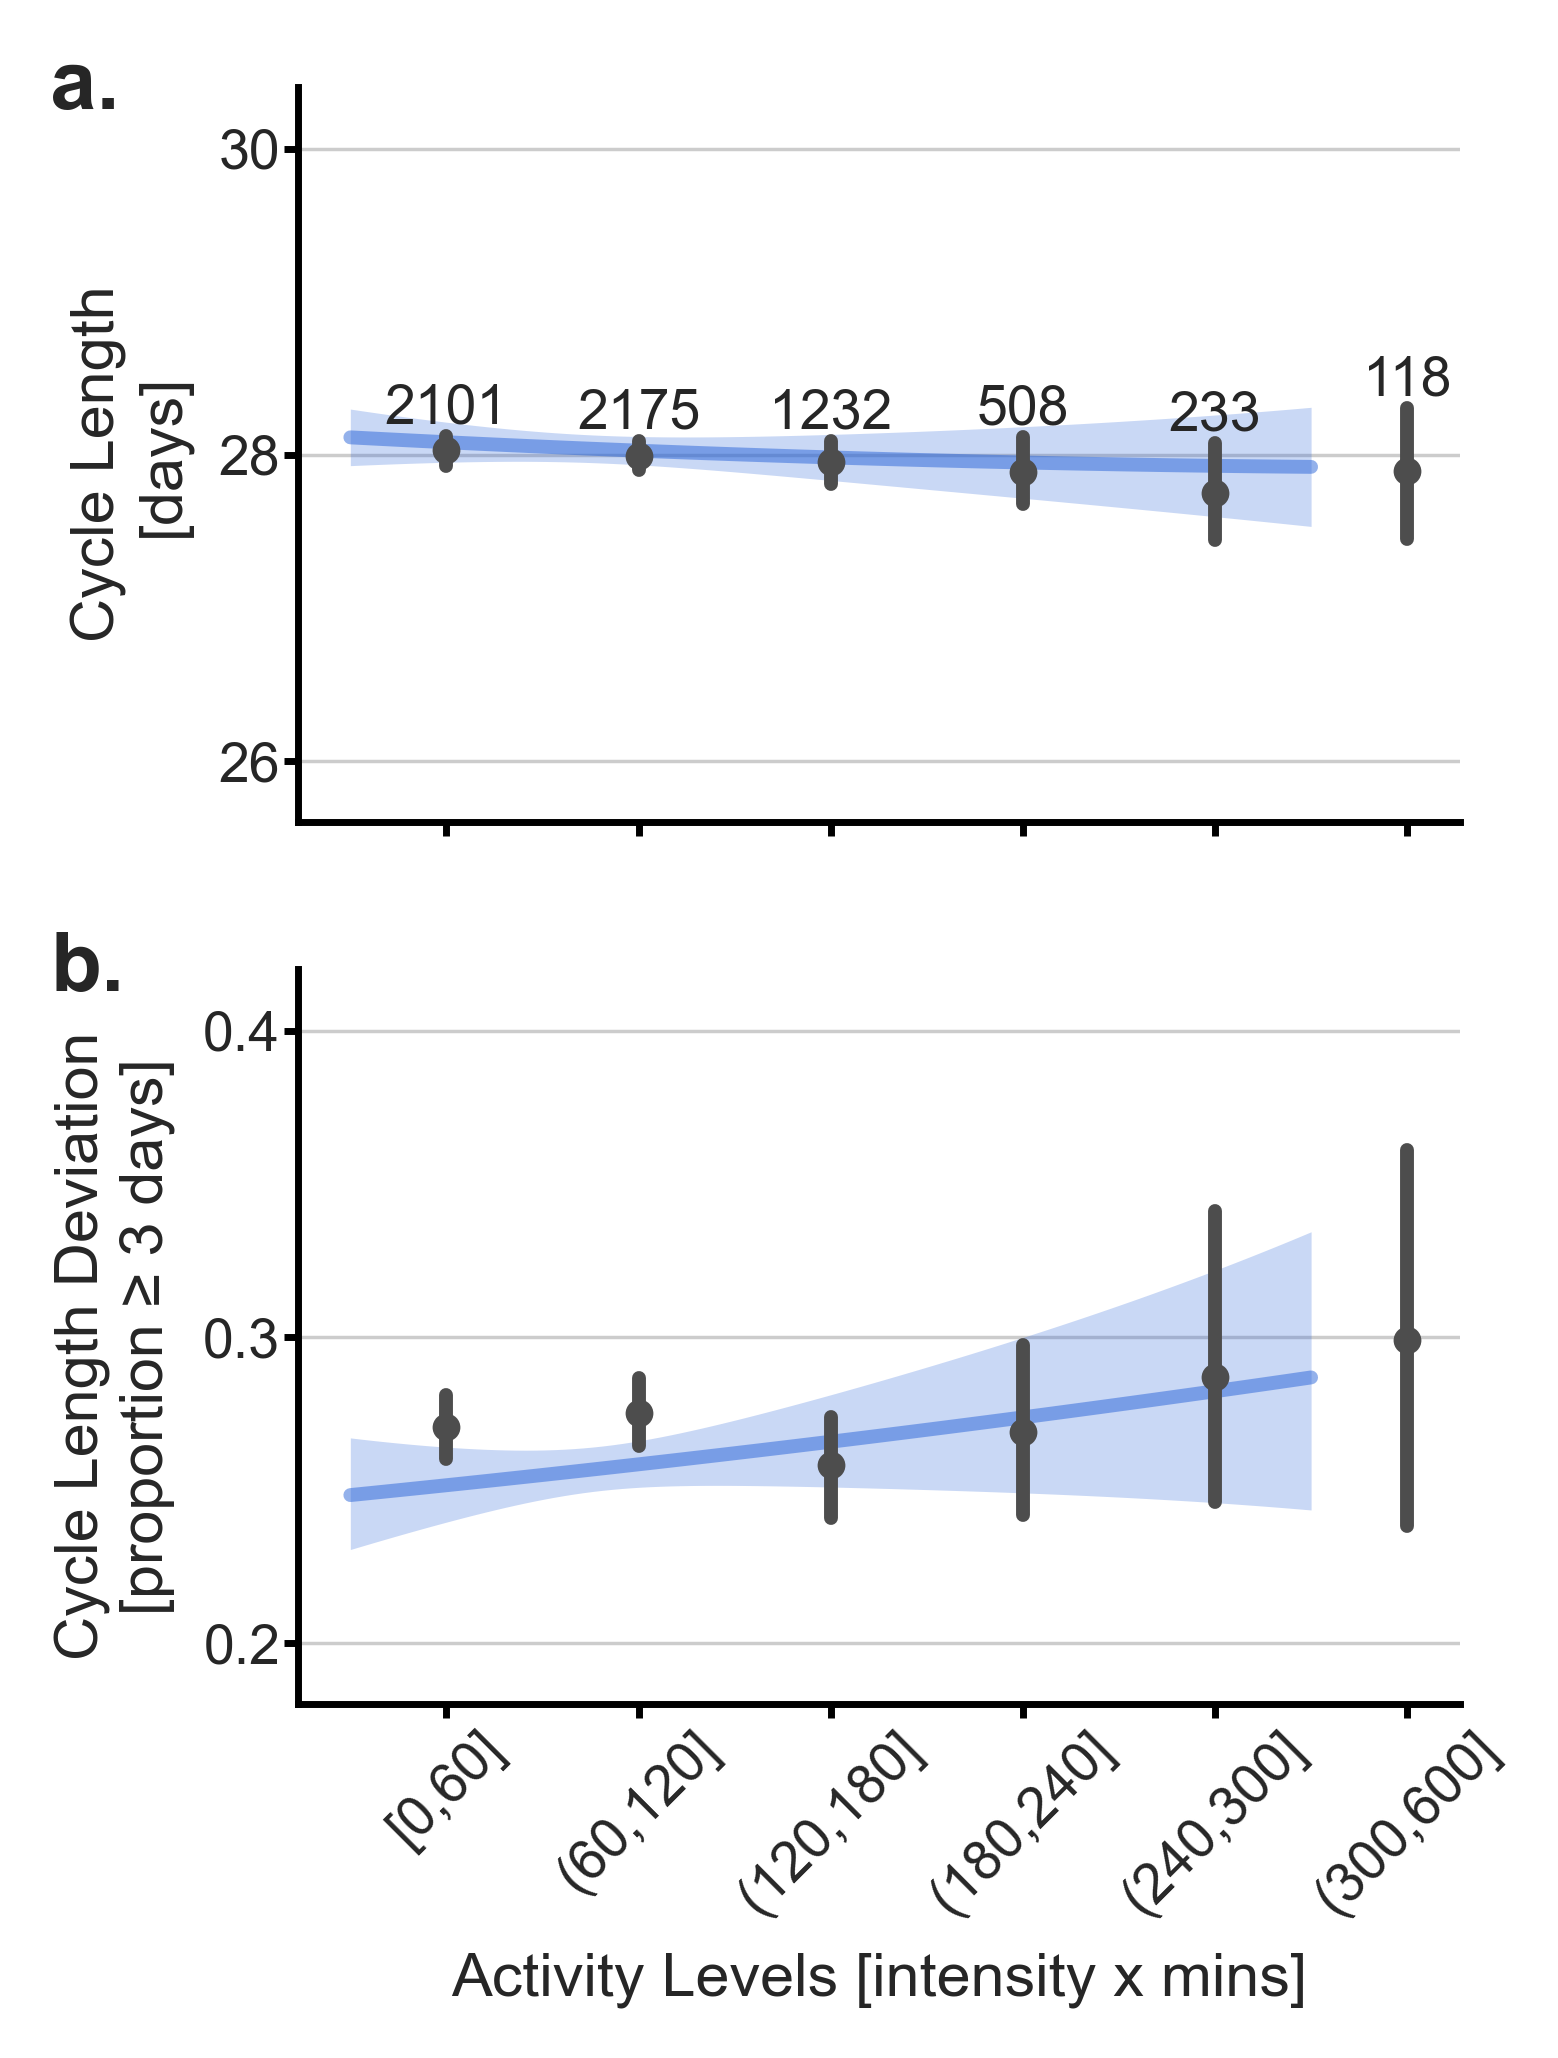

In [9]:
f, ax = cla.cl_x_behav_plots(behavior='wo', safe_fig=False)
plt.show()

## Figure S4 — within-user cycle-length SD vs age

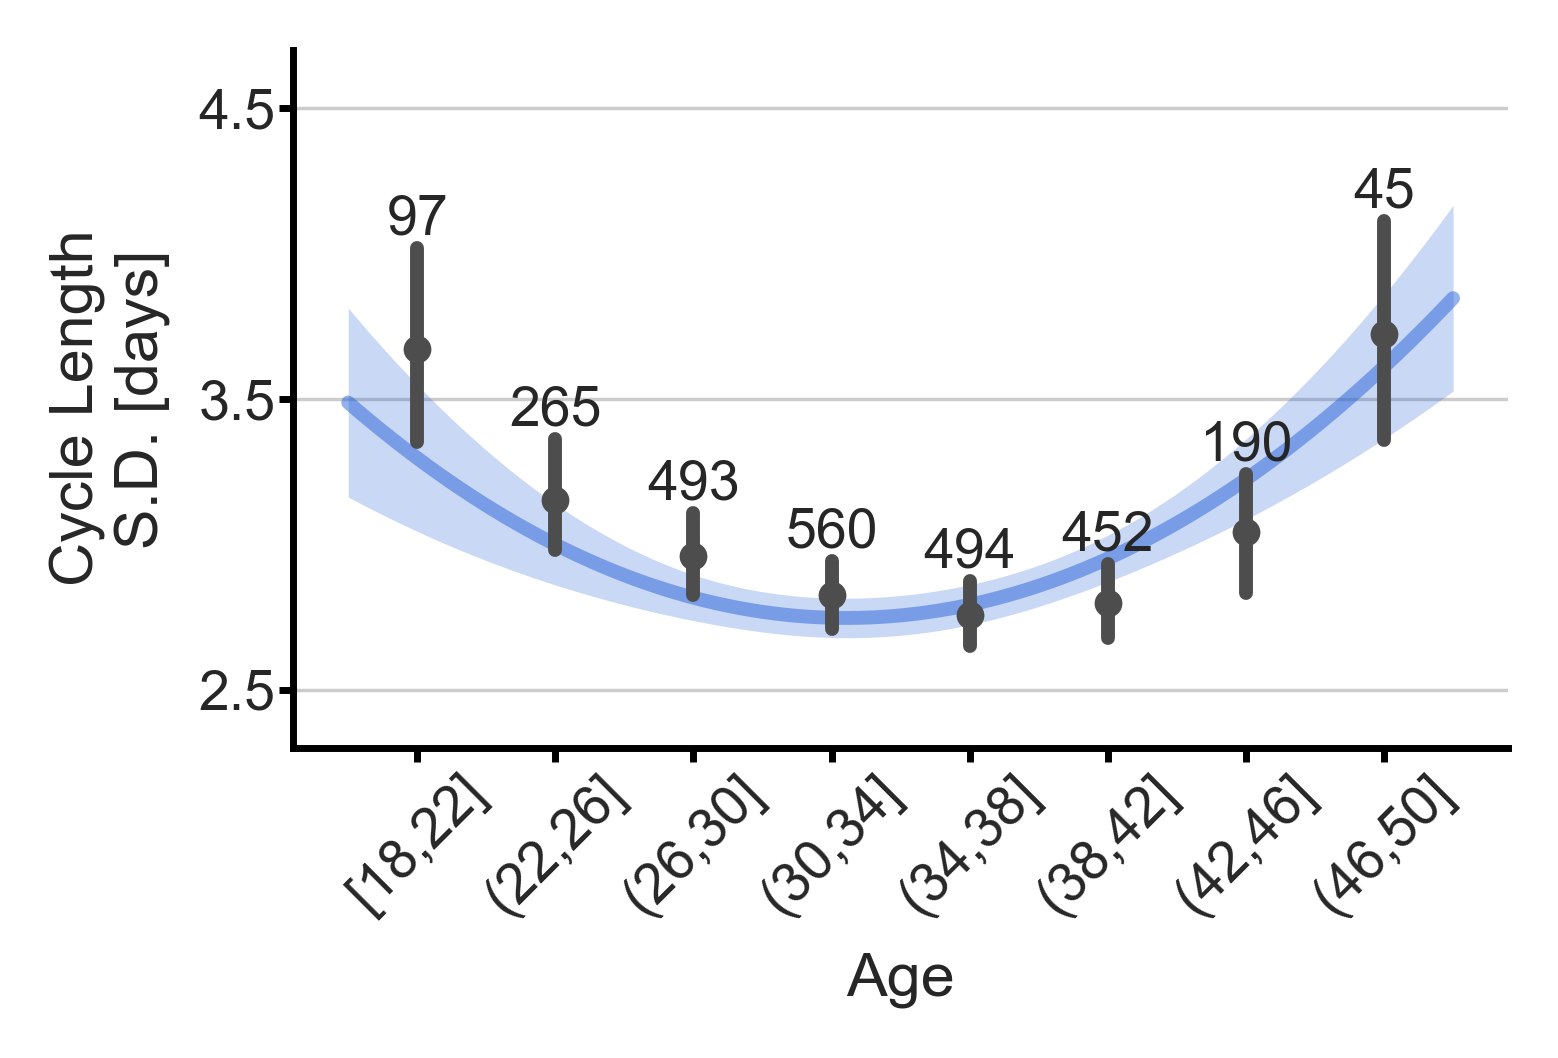

In [10]:
f, ax = cla.cl_sd_x_age_plot()
plt.show()